# Streaming spike inference: a sparse QP re-solved on every window of a signal

Calcium imaging reports a neuron's activity through a fluorescence trace. Each spike adds a jump
to the calcium concentration, which then decays. A standard model (Vogelstein et al., 2010;
Friedrich, Zhou and Paninski, 2017) is the autoregression

$$
c_t = \gamma\, c_{t-1} + s_t, \qquad s_t \ge 0, \qquad y_t = c_t + \text{noise},
$$

and the spikes are recovered by nonnegative sparse deconvolution:

$$
\min_{c}\ \tfrac12 \|y - c\|^2 + \lambda\, \mathbf 1^\top s \quad \text{s.t.}\quad s = Dc \ge 0,
\qquad (Dc)_t = c_t - \gamma c_{t-1}.
$$

On an embedded acquisition system this QP is solved again for every new window of $W$ samples,
with the last calcium level of the previous window as the initial condition. The problem's
*structure* never changes. Its *data* ($y$, $\gamma$, $\lambda$ and the initial level) change
every time. That is the case Scaly's generated solvers are made for.

The notebook also shows that **the formulation decides the cost**:

- in the variables $c$, the Hessian is the identity and the constraint matrix $D$ is bidiagonal,
  so the problem has $O(W)$ nonzeros;
- eliminating $c = Ks$ gives a problem in $s$ with only bounds, but a dense $W \times W$ Hessian
  $K^\top K$, where $K$ is the lower-triangular matrix of powers of $\gamma$.

Scaly extracts both QPs from the same kind of symbolic model and derives their sparsity patterns.
PIQP then solves them.

| Scaly feature | Where |
| --- | --- |
| `sc.problem` with a parameter tree, proven quadratic | the QP, with $\gamma$ inside the constraint matrix |
| `sc.solver(..., "piqp", options={"sparse": True})` | patterns of $P$ and $G$ baked into the wrapper |
| one generated solver called in a loop | the streaming estimator |

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize

import plotstyle
import scaly as sc
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "spike_deconvolution"
rng = np.random.default_rng(5)
TIGHT = {"eps_abs": 1e-9, "eps_rel": 1e-9, "eps_duality_gap_abs": 1e-9, "eps_duality_gap_rel": 1e-9}

## A synthetic recording

The recording is 30 s at 50 Hz with a decay time of 0.5 s, so $\gamma = e^{-1/25}$. Spikes arrive
as a Poisson process whose rate itself switches on and off in bursts. Spike amplitudes vary, and
the noise standard deviation is 0.25 of a unit spike.

In [2]:
FS, SECONDS, TAU = 50.0, 30.0, 0.5
T = int(FS * SECONDS)
GAMMA = np.exp(-1 / (TAU * FS))
rate = np.where(np.sin(2 * np.pi * np.arange(T) / (4 * FS)) > 0.3, 3.0, 0.3) / FS
spikes = rng.poisson(rate) * rng.uniform(0.6, 1.4, T)
calcium = np.zeros(T)
for t in range(T):
  calcium[t] = (GAMMA * calcium[t - 1] if t else 0.0) + spikes[t]
SIGMA = 0.25
y_all = calcium + SIGMA * rng.standard_normal(T)
print(f"{T} samples, {np.count_nonzero(spikes)} spikes, gamma = {GAMMA:.4f}")

1500 samples, 46 spikes, gamma = 0.9608


## The window problem, in the calcium variables

The window has $W = 100$ samples (2 s). The parameters are the window's data, the calcium level
$c_0$ just before it, $\gamma$ and $\lambda$. $\gamma$ enters the constraint matrix, so the matrix is
parameter data. Its *pattern*, the diagonal and the subdiagonal, is fixed, and that is all the
sparse PIQP path needs.

In [3]:
W = 100


def window_problem(width):
  @sc.problem(vars=sc.L("c", width), params=sc.G(sc.L("y", width), sc.L("c0", ()), sc.L("gamma", ()), sc.L("lam", ())))
  def deconvolution(c, params):
    y, c0, gamma, lam = params
    s = c - gamma * sc.concat([c0.reshape((1,)), c[:-1]])
    return sc.ProblemSpec(minimize=0.5 * sc.sumsqr(y - c) + lam * s.sum(), ineq=(sc.bounded(s, lo=0.0, name="spikes"),))

  return deconvolution


problem = window_problem(W)
solve_c = sc.solver(problem, "piqp", name="deconv_sparse", options={"sparse": True, **TIGHT})


def solve_window(solver, y, c0, lam=0.4, width=W):
  c, *_ = solver(np.zeros(width), np.zeros(width), np.zeros(0), np.zeros(width), (y, np.array(c0), np.array(GAMMA), np.array(lam)))
  return c


c_hat = solve_window(solve_c, y_all[:W], 0.0)
print(f"status {sc.solver_stats(solve_c).to_solver_status().name}, {sc.solver_stats(solve_c).iter} PIQP iterations")

status OK, 8 PIQP iterations


### An independent check

In the spike variables the same problem is $\min_{s \ge 0} \tfrac12\|y - Ks - \gamma^{t} c_0\|^2 + \lambda \mathbf 1^\top s$.
That is a smooth objective with bounds, which SciPy's L-BFGS-B solves to high accuracy.

In [4]:
def spike_matrix(width, gamma=GAMMA):
  t = np.arange(width)
  return np.tril(gamma ** (t[:, None] - t[None, :]).clip(0))


def reference(y, c0, lam=0.4):
  k = spike_matrix(len(y))
  decay = GAMMA ** np.arange(1, len(y) + 1) * c0
  fun = lambda s: (0.5 * np.sum((y - k @ s - decay) ** 2) + lam * s.sum(), -(k.T @ (y - k @ s - decay)) + lam)
  res = optimize.minimize(
    fun, np.zeros(len(y)), jac=True, method="L-BFGS-B", bounds=[(0, None)] * len(y), options={"ftol": 1e-15, "gtol": 1e-12, "maxiter": 10_000}
  )
  return k @ res.x + decay


print(f"|c_PIQP - c_L-BFGS-B|_inf = {np.abs(c_hat - reference(y_all[:W], 0.0)).max():.1e}")

|c_PIQP - c_L-BFGS-B|_inf = 2.7e-07


## The streaming estimator

The stream is cut into consecutive windows. Each window starts from the last calcium level of the
previous estimate. The whole 30 s recording is one call of the generated solver per window.

In [5]:
def stream(solver, width, lam=0.4):
  c_est, c0, times = [], 0.0, []
  for start in range(0, T - width + 1, width):
    tic = time.perf_counter()
    c = solve_window(solver, y_all[start : start + width], c0, lam, width)
    times.append(time.perf_counter() - tic)
    c_est.append(c)
    c0 = c[-1]
  c_est = np.concatenate(c_est)
  return c_est, np.diff(np.r_[0.0, c_est]) + (1 - GAMMA) * np.r_[0.0, c_est[:-1]], np.array(times)


c_stream, s_stream, times = stream(solve_c, W)
print(f"{len(times)} windows of {W} samples: median {1e6 * np.median(times):.0f} µs per window (including the Python call)")
print(f"calcium RMS error {np.sqrt(np.mean((c_stream - calcium) ** 2)):.3f}, against {SIGMA:.3f} in the raw trace")

15 windows of 100 samples: median 240 µs per window (including the Python call)
calcium RMS error 0.090, against 0.250 in the raw trace


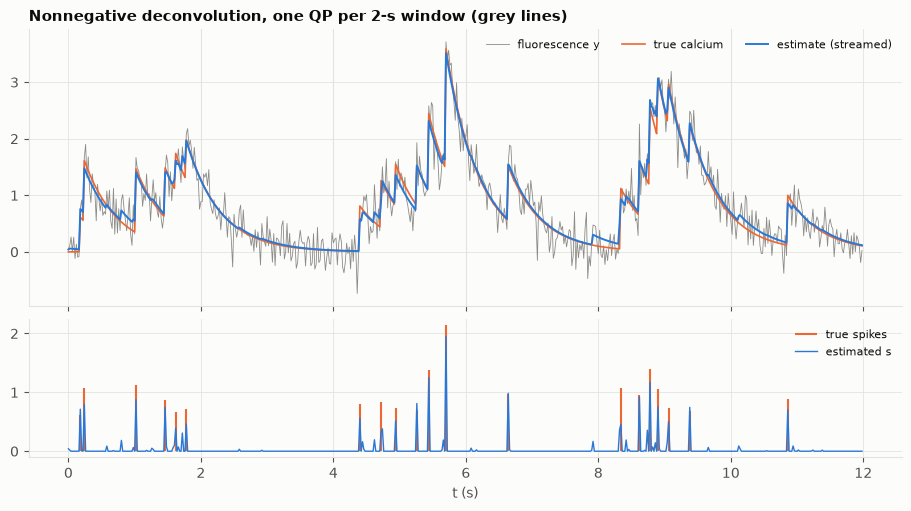

In [6]:
tt = np.arange(T) / FS
view = tt < 12
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(tt[view], y_all[view], color=plotstyle.NEUTRAL, lw=0.6, label="fluorescence y")
ax1.plot(tt[view], calcium[view], color=plotstyle.ORANGE, lw=1.2, label="true calcium")
ax1.plot(tt[view], c_stream[view], color=plotstyle.BLUE, lw=1.4, label="estimate (streamed)")
for edge in np.arange(W, 12 * FS, W) / FS:
  ax1.axvline(edge, color=plotstyle.GRID, lw=0.8, zorder=0)
ax1.set_title("Nonnegative deconvolution, one QP per 2-s window (grey lines)")
ax1.legend(fontsize=8, ncol=3, loc="upper right")
ax2.vlines(tt[view][spikes[view] > 0], 0, spikes[view][spikes[view] > 0], color=plotstyle.ORANGE, lw=1.5, label="true spikes")
ax2.plot(tt[view], s_stream[view], color=plotstyle.BLUE, lw=1, label="estimated s")
ax2.set_xlabel("t (s)")
ax2.legend(fontsize=8, loc="upper right")
plt.show()

## Sparse against dense formulation

The same window problem in the spike variables has bounds only, but a dense Hessian. Both are
built for several window lengths from Scaly models, and both are solved by PIQP. The sparse one
uses the compressed pattern, the dense one PIQP's dense interface.

In [7]:
def dense_window_problem(width):
  k = sc.const(spike_matrix(width))
  decay = sc.const(GAMMA ** np.arange(1, width + 1))

  @sc.problem(vars=sc.L("s", width), params=sc.G(sc.L("y", width), sc.L("c0", ()), sc.L("lam", ())))
  def deconvolution_s(s, params):
    y, c0, lam = params
    return sc.ProblemSpec(minimize=0.5 * sc.sumsqr(y - k @ s - decay * c0) + lam * s.sum(), lb=sc.const(np.zeros(width)))

  return deconvolution_s


def per_solve(fn, repeat=50):
  fn()
  start = time.perf_counter()
  for _ in range(repeat):
    fn()
  return (time.perf_counter() - start) / repeat


rows = []
for width in (25, 50, 100):
  y = y_all[:width]
  sparse_solver = sc.solver(window_problem(width), "piqp", name=f"deconv_c_{width}", options={"sparse": True, **TIGHT})
  dense_solver = sc.solver(dense_window_problem(width), "piqp", name=f"deconv_s_{width}", options=TIGHT)
  sparse_run = lambda: solve_window(sparse_solver, y, 0.0, 0.4, width)
  dense_run = lambda: dense_solver(np.zeros(width), np.zeros(width), np.zeros(0), np.zeros(0), (y, np.array(0.0), np.array(0.4)))
  s_dense = dense_run()[0]
  agree = np.abs(spike_matrix(width) @ s_dense - sparse_run()).max()
  rows.append((width, per_solve(sparse_run), per_solve(dense_run), agree))
  print(
    f"W = {width:3d}: sparse (c) {1e6 * rows[-1][1]:7.0f} µs, dense (s) {1e6 * rows[-1][2]:7.0f} µs per solve; calcium estimates agree to {agree:.0e}"
  )

W =  25: sparse (c)      99 µs, dense (s)     137 µs per solve; calcium estimates agree to 1e-06


W =  50: sparse (c)     146 µs, dense (s)     311 µs per solve; calcium estimates agree to 6e-08


W = 100: sparse (c)     247 µs, dense (s)    1308 µs per solve; calcium estimates agree to 6e-07


At these sizes the sparse formulation's time is mostly fixed overhead and grows slowly with $W$.
The dense one's grows roughly quadratically. Scaly found both patterns from the models, which were written without any sparse-matrix
bookkeeping.

## The generated C

The streaming solver is a C function with a fixed signature: the window's samples and three
scalars in, the calcium estimate and multipliers out. It links against the vendored PIQP and
keeps its workspace between calls.

In [8]:
module = write_module(solve_c, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB")

deconv_sparse.c: 602 lines, 37 kB
